In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
dataset = load_dataset("cnamuangtoun/resume-job-description-fit")
print(dataset)

train.csv:   0%|          | 0.00/53.4M [00:00<?, ?B/s]

d:\anaconda2\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\My home PC\.cache\huggingface\hub\datasets--cnamuangtoun--resume-job-description-fit. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


test.csv:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1759 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['resume_text', 'job_description_text', 'label'],
        num_rows: 6241
    })
    test: Dataset({
        features: ['resume_text', 'job_description_text', 'label'],
        num_rows: 1759
    })
})


In [4]:
train_df = dataset['train'].to_pandas()
test_df  = dataset['test'].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (6241, 3)
Test shape:  (1759, 3)


In [5]:
print("=== Column names & dtypes ===")
print(train_df.dtypes)

print("\n=== Missing values (train) ===")
print(train_df.isnull().sum())

print("\n=== Missing values (test) ===")
print(test_df.isnull().sum())

print("\n=== First row preview ===")
print(train_df.iloc[0])

=== Column names & dtypes ===
resume_text             object
job_description_text    object
label                   object
dtype: object

=== Missing values (train) ===
resume_text             0
job_description_text    0
label                   0
dtype: int64

=== Missing values (test) ===
resume_text             0
job_description_text    0
label                   0
dtype: int64

=== First row preview ===
resume_text             SummaryHighly motivated Sales Associate with e...
job_description_text    Net2Source Inc. is an award-winning total work...
label                                                              No Fit
Name: 0, dtype: object


=== Train label distribution ===
               count  percent
label                        
No Fit          3143    50.36
Potential Fit   1556    24.93
Good Fit        1542    24.71

=== Test label distribution ===
               count  percent
label                        
No Fit           857    48.72
Good Fit         458    26.04
Potential Fit    444    25.24


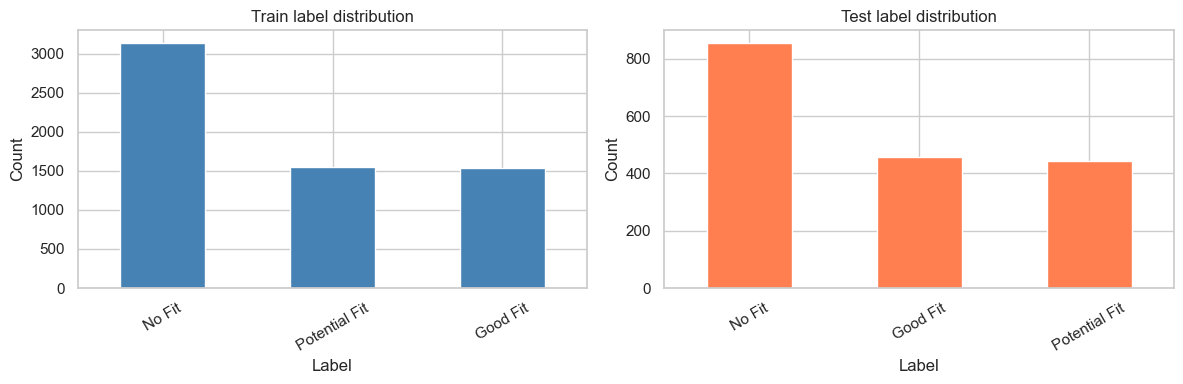

In [6]:
print("=== Train label distribution ===")
train_counts = train_df['label'].value_counts()
train_pct    = train_df['label'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': train_counts, 'percent': train_pct.round(2)}))

print("\n=== Test label distribution ===")
test_counts = test_df['label'].value_counts()
test_pct    = test_df['label'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': test_counts, 'percent': test_pct.round(2)}))

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_counts.plot(kind='bar', ax=axes[0], title='Train label distribution', color='steelblue')
test_counts.plot(kind='bar',  ax=axes[1], title='Test label distribution',  color='coral')
for ax in axes:
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("../reports/figures/label_distribution.png", dpi=150)
plt.show()

=== Resume word count (train) ===
count    6241.0
mean      708.1
std       391.7
min        84.0
25%       488.0
50%       618.0
75%       810.0
95%      1591.0
max      3134.0
Name: resume_word_count, dtype: float64

=== JD word count (train) ===
count    6241.0
mean      371.5
std       239.1
min        11.0
25%       169.0
50%       328.0
75%       532.0
95%       810.0
max      1079.0
Name: jd_word_count, dtype: float64


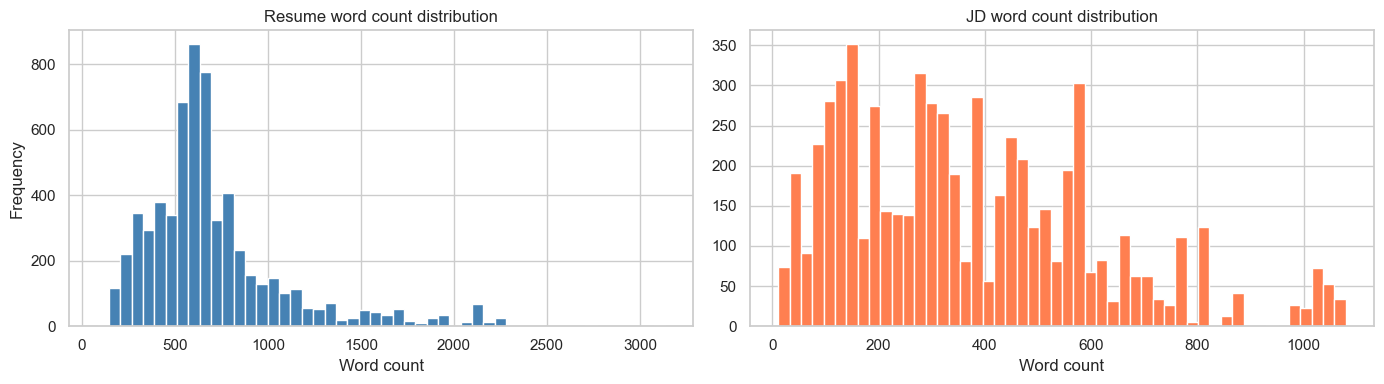

In [7]:
train_df['resume_word_count'] = train_df['resume_text'].str.split().str.len()
train_df['jd_word_count']     = train_df['job_description_text'].str.split().str.len()

print("=== Resume word count (train) ===")
print(train_df['resume_word_count'].describe(percentiles=[.25, .5, .75, .95]).round(1))

print("\n=== JD word count (train) ===")
print(train_df['jd_word_count'].describe(percentiles=[.25, .5, .75, .95]).round(1))

# Histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_df['resume_word_count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Resume word count distribution")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Frequency")

axes[1].hist(train_df['jd_word_count'], bins=50, color='coral', edgecolor='white')
axes[1].set_title("JD word count distribution")
axes[1].set_xlabel("Word count")

plt.tight_layout()
plt.savefig("../reports/figures/text_length_distribution.png", dpi=150)
plt.show()

In [8]:
pd.set_option('display.max_colwidth', None)

for label in train_df['label'].unique():
    print(f"\n{'='*60}")
    print(f"LABEL: {label}")
    print(f"{'='*60}")
    samples = train_df[train_df['label'] == label].sample(2, random_state=42)
    for i, row in samples.iterrows():
        print(f"\n--- Example (index {i}) ---")
        print(f"\n[RESUME]\n{row['resume_text'][:800]}")
        print(f"\n[JOB DESCRIPTION]\n{row['job_description_text'][:800]}")
        print()


LABEL: No Fit

--- Example (index 2993) ---

[RESUME]
Professional SummaryAdept at managing budgets, payroll, invoicing and general accounting functions. Instrumental in keeping business operations fully compliant and working within budgetary guidelines.
SkillsAccounts Payable and ReceivableBudget Forecasting ExpertiseTax Law UnderstandingTax PreparationMS Office SuiteAccount Reconciliation ProcessesPayroll ManagementPayroll Liability and DeductionsStock Valuation
Work History01/2022to06/2023AccountantBurrell Behavioral Health|Fordland,,UAeDocumented cash, credit, fixed assets, accrued expenses, and line of credit transactions.Completed daily cash functions like account tracking, payroll and wage allocations, budgeting, donating, and cash, and banking reconciliations.Reconciled accounts and reviewed expense data, net worth, and assets.Evaluat

[JOB DESCRIPTION]
Position Title: Senior Accountant Organization: Jewish Family Service of San Diego Department: Family and Community Services 

In [9]:
print("=== Exact duplicate rows ===")
print("Train:", train_df.duplicated().sum())
print("Test: ", test_df.duplicated().sum())

print("\n=== Duplicate JDs within train ===")
print(train_df['job_description_text'].duplicated().sum())

print("\n=== Duplicate JDs within test ===")
print(test_df['job_description_text'].duplicated().sum())

print("\n=== JD overlap between train and test (leakage check) ===")
train_jds = set(train_df['job_description_text'].tolist())
test_jds  = set(test_df['job_description_text'].tolist())
overlap   = train_jds.intersection(test_jds)
print(f"Overlapping JD texts: {len(overlap)}")

print("\n=== Resume overlap between train and test ===")
train_res = set(train_df['resume_text'].tolist())
test_res  = set(test_df['resume_text'].tolist())
print(f"Overlapping resume texts: {len(train_res.intersection(test_res))}")

=== Exact duplicate rows ===
Train: 1
Test:  0

=== Duplicate JDs within train ===
5961

=== Duplicate JDs within test ===
1688

=== JD overlap between train and test (leakage check) ===
Overlapping JD texts: 0

=== Resume overlap between train and test ===
Overlapping resume texts: 476
